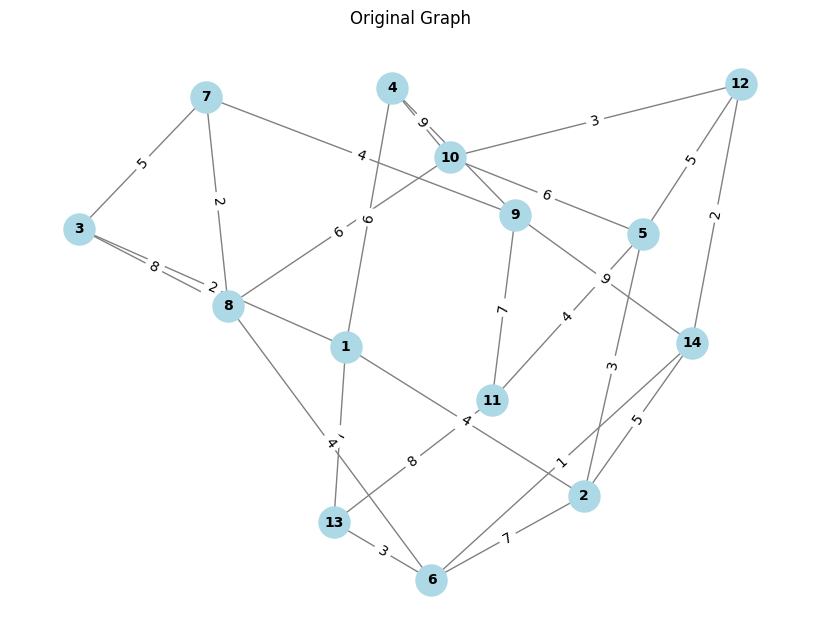

BFS Traversal Order: [5, 2, 11, 12, 10, 1, 6, 14, 9, 13, 4, 8, 3, 7]


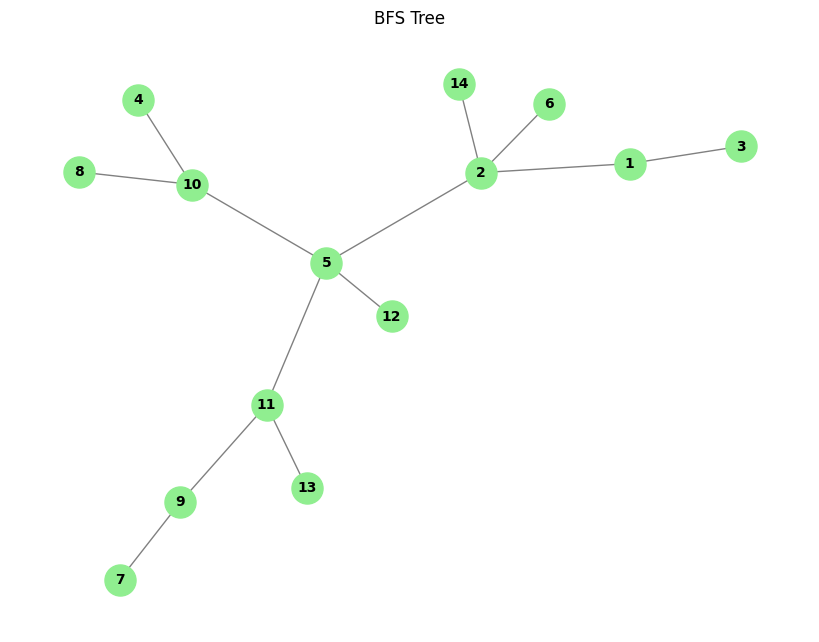


Best-First Search Traversal (7 to 2):
7 8 6 14 12 10 13 9 2 
Reached the goal.


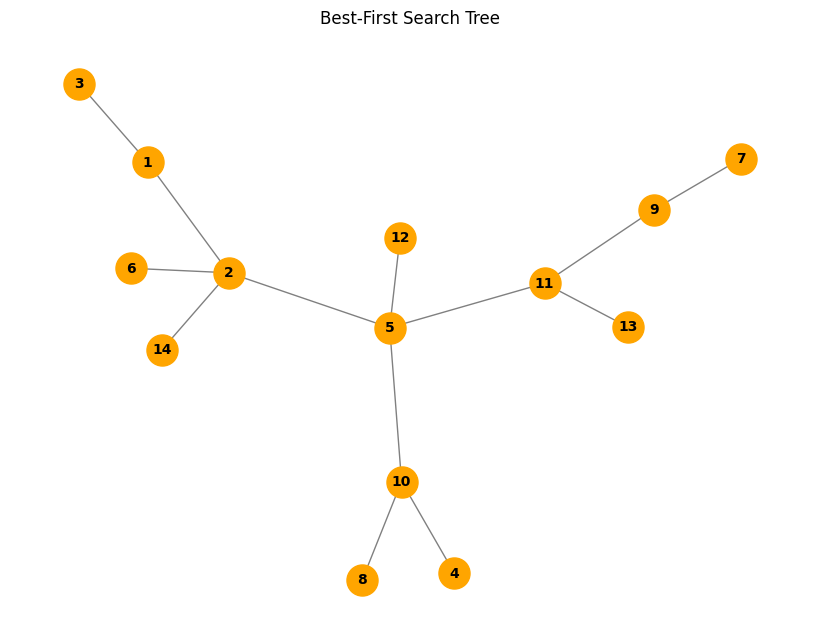

In [16]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import heapq

def print_og_graph(graph_file_path):
    graph_data = pd.read_csv(graph_file_path)

    # Create undirected graph from CSV
    G = nx.Graph()
    for _, row in graph_data.iterrows():
        G.add_edge(int(row['start_node']), int(row['end_node']), weight=int(row['weight']))

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=500, font_size=10, font_weight='bold', edge_color='gray')
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Original Graph")
    plt.show()

def breadth_first_search(source, graph_file_path):
    graph_data = pd.read_csv(graph_file_path)
    graph = {}

    for _, row in graph_data.iterrows():
        start = int(row['start_node'])
        end = int(row['end_node'])

        if start not in graph:
            graph[start] = []
        if end not in graph:
            graph[end] = []

        graph[start].append(end)
        graph[end].append(start)

    # BFS traversal
    bfs_order = []
    parent = {source: None}
    q = deque([source])

    while q:
        node = q.popleft()
        bfs_order.append(node)

        for neighbor in graph[node]:
            if neighbor not in parent:
                parent[neighbor] = node
                q.append(neighbor)

    return parent, bfs_order

def best_first_search(graph_file_path, start, goal):
    graph_data = pd.read_csv(graph_file_path)
    graph = {}

    for _, row in graph_data.iterrows():
        start_node = int(row['start_node'])
        end_node = int(row['end_node'])
        weight = int(row['weight'])

        if start_node not in graph:
            graph[start_node] = []
        if end_node not in graph:
            graph[end_node] = []

        graph[start_node].append((end_node, weight))
        graph[end_node].append((start_node, weight))  # Since it's an undirected graph

    visited = set()
    priority_queue = []
    heapq.heappush(priority_queue, (0, start))  # Start with heuristic 0

    print("\nBest-First Search Traversal ({} to {}):".format(start, goal))
    while priority_queue:
        _, node = heapq.heappop(priority_queue)  # Node with the lowest heuristic
        if node in visited:
            continue

        print(node, end=" ")
        visited.add(node)

        if node == goal:
            print("\nReached the goal.")
            return

        if node in graph:
            for neighbor, heuristic in graph[node]:
                if neighbor not in visited:
                    heapq.heappush(priority_queue, (heuristic, neighbor))

    print("\nGoal not reachable.")

def plot_bfs_tree(parent, bfs_order):
    G = nx.Graph()

    # Add BFS tree edges
    for child, p in parent.items():
        if p is not None:
            G.add_edge(p, child)

    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightgreen',
            node_size=500, font_size=10, font_weight='bold', edge_color='gray')
    plt.title("BFS Tree")
    plt.show()

def plot_best_first_tree(parent):
    G = nx.Graph()

    # Add Best-First tree edges
    for child, p in parent.items():
        if p is not None:
            G.add_edge(p, child)

    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='orange',
            node_size=500, font_size=10, font_weight='bold', edge_color='gray')
    plt.title("Best-First Search Tree")
    plt.show()

# Execution
graph_file_path = r"C:\Users\aarya\Desktop\3rd YEAR\sem 6\AI lab\new_graph_nodes.csv" 

print_og_graph(graph_file_path)

# BFS Execution
source_node = int(input("Enter the source node for BFS: "))
parent, bfs_order = breadth_first_search(source_node, graph_file_path)
print("BFS Traversal Order:", bfs_order)
plot_bfs_tree(parent, bfs_order)

# Best-First Search Execution
start_node = int(input("Enter the start node for Best-First Search: "))
end_node = int(input("Enter the goal node for Best-First Search: "))
best_first_search(graph_file_path, start_node, end_node)
plot_best_first_tree(parent)


In [1]:
import pandas as pd 
import networkx as nx 
import matplotlib.pyplot as plt 
from queue import PriorityQueue 
from collections import deque 
 
def read_weighted_graph_from_csv(filename): 
     
    df = pd.read_csv(filename) 
    graph = {} 
    for _, row in df.iterrows(): 
        u = str(row["Source"]).strip() 
        v = str(row["Destination"]).strip() 
        try: 
            cost = float(row["Weight"]) 
        except (ValueError, TypeError): 
            cost = 1.0 
        if u not in graph: 
            graph[u] = [] 
        graph[u].append((v, cost)) 
        # Ensure the destination appears even if it has no outgoing edges. 
        if v not in graph: 
            graph[v] = [] 
    return graph 
 
 
def best_first_search(graph, heuristic, start, target): 
    
    visited = set() 
    pq = PriorityQueue() 
    parent = {} 
    parent[start] = None 
    pq.put((heuristic[start], start, [])) 
     
    while not pq.empty(): 
        h_val, u, path = pq.get() 
        path = path + [u] 
        if u == target: 
            return path, parent 
        if u not in visited: 
            visited.add(u) 
            for v, cost in graph.get(u, []): 
                if v not in visited and v not in parent: 
                    parent[v] = u 
                    pq.put((heuristic[v], v, path)) 
    return [], parent 
 
class GraphVisualization: 
    def compute_positions(self, edges, start_node): 
         
        tempG = nx.DiGraph() 
        for e in edges: 
            if len(e) == 2: 
                u, v = e 
            else: 
                u, v, _ = e 
            tempG.add_edge(u, v) 
        # If start_node is not in tempG, add it to avoid KeyError. 
        if start_node not in tempG: 
            tempG.add_node(start_node) 
        # Compute BFS levels starting from start_node. 
        levels = {start_node: 0} 
        queue = deque([start_node]) 
        while queue: 
            node = queue.popleft() 
            for neighbor in tempG.successors(node): 
                if neighbor not in levels: 
                    levels[neighbor] = levels[node] + 1 
                    queue.append(neighbor) 
        # Group nodes by level. 
        level_nodes = {} 
        for node, lvl in levels.items(): 
            level_nodes.setdefault(lvl, []).append(node) 
        pos = {} 
        for lvl, nodes in level_nodes.items(): 
            nodes_sorted = sorted(nodes) 
            for i, node in enumerate(nodes_sorted): 
                x = 0.5 if len(nodes_sorted) == 1 else (i + 1) / (len(nodes_sorted) + 1) 
                pos[node] = (x, -lvl) 
        return pos 
 
    def compute_positions_for_path(self, path): 
         
        pos = {} 
        n = len(path) 
        for i, node in enumerate(path): 
            pos[node] = ((i+1)/(n+1), 0) 
        return pos 
 
    def visualize_all(self, original_edges, optimal_path, source, target): 
         
        # Build the original graph. 
        orig_graph = nx.DiGraph() 
        orig_graph.add_weighted_edges_from(original_edges) 
         
        all_paths = list(nx.all_simple_paths(orig_graph, source, target)) 
        union_edges = set() 
        for path in all_paths: 
            for u, v in zip(path, path[1:]): 
                union_edges.add((u, v)) 
        nonopt_graph = nx.DiGraph() 
        nonopt_graph.add_edges_from(union_edges) 
         
        #non-optimal 
        non_optimal_path = None 
        for p in all_paths: 
            if p != optimal_path: 
                non_optimal_path = p 
                break 
        if non_optimal_path is None and all_paths: 
            non_optimal_path = all_paths[0] 
         
        # optimal 
        opt_graph = nx.DiGraph() 
        opt_edges = list(zip(optimal_path, optimal_path[1:])) 
        opt_graph.add_edges_from(opt_edges) 
         
        fig, axes = plt.subplots(1, 3, figsize=(18, 6)) 
         
        axes[0].set_title("Original Weighted Directed Graph") 
        pos_orig = nx.spring_layout(orig_graph) 
        nx.draw(orig_graph, pos=pos_orig, ax=axes[0], with_labels=True, 
                node_color='lightblue', node_size=500, edge_color='gray', arrows=True) 
        edge_labels_orig = nx.get_edge_attributes(orig_graph, 'weight') 
        nx.draw_networkx_edge_labels(orig_graph, pos_orig, 
edge_labels=edge_labels_orig, ax=axes[0]) 
         
        axes[1].set_title("Optimal Path (Least Cost)") 
        pos_opt = self.compute_positions_for_path(optimal_path) 
        nx.draw(opt_graph, pos=pos_opt, ax=axes[1], with_labels=True, 
                node_color='lightgreen', node_size=500, edge_color='red', arrows=True) 
        edge_labels_opt = {} 
        for u, v in opt_edges: 
            for edge in original_edges: 
                if edge[0] == u and edge[1] == v: 
                    edge_labels_opt[(u, v)] = edge[2] 
                    break 
        nx.draw_networkx_edge_labels(opt_graph, pos_opt, edge_labels=edge_labels_opt, 
ax=axes[1]) 
         
        axes[2].set_title("Non-Optimal Paths") 
        pos_nonopt = self.compute_positions(list(nonopt_graph.edges()), source) 
        nx.draw(nonopt_graph, pos=pos_nonopt, ax=axes[2], with_labels=True, 
                node_color='salmon', node_size=500, edge_color='gray', arrows=True) 
        edge_labels_nonopt = {} 
        for u, v in nonopt_graph.edges(): 
            for edge in original_edges: 
                if edge[0] == u and edge[1] == v: 
                    edge_labels_nonopt[(u, v)] = edge[2] 
                    break 
        nx.draw_networkx_edge_labels(nonopt_graph, pos_nonopt, 
edge_labels=edge_labels_nonopt, ax=axes[2]) 
        if non_optimal_path and len(non_optimal_path) > 1: 
            nonopt_path_edges = list(zip(non_optimal_path, non_optimal_path[1:])) 
            nx.draw_networkx_edges(nonopt_graph, pos_nonopt, 
edgelist=nonopt_path_edges, 
                                   edge_color='blue', width=2, arrows=True, ax=axes[2]) 
         
        plt.tight_layout() 
        plt.show() 
 
def main(): 
    graph_filename = "graphNodes.csv"  
    graph = read_weighted_graph_from_csv(graph_filename) 
     
    heuristic = { 
        'A': 7, 
        'B': 6, 
        'C': 5, 
        'D': 4, 
        'E': 3, 
        'F': 0,   # Destination F 
        'G': 2, 
        'H': 3, 
        'I': 2, 
        'J': 4, 
        'K': 3, 
        'L': 2, 
        'M': 2, 
        'N': 1, 
        'O': 2 
    } 
     
    print("Nodes in the graph:", list(graph.keys())) 
    source = input("Enter source node: ").strip() 
    target = "F"   
    print("Destination node is hardcoded as 'F'") 
     
    if source == target: 
        print("Source is the same as target. Optimal path is trivial.") 
        return 
     
    if source not in graph or target not in heuristic: 
        print("Invalid node(s)! Check your input.") 
        return 
     
    optimal_path, parent = best_first_search(graph, heuristic, source, target) 
    if optimal_path: 
        print("Optimal (Least-Cost) Path:", " -> ".join(optimal_path)) 
    else: 
        print("No path found.") 
        return 
     
    original_edges = [] 
    for u in graph: 
        for v, cost in graph[u]: 
            original_edges.append((u, v, cost)) 
     
    gv = GraphVisualization() 
    gv.visualize_all(original_edges, optimal_path, source, target) 
 
if __name__ == "__main__": 
    main() 

KeyError: 'Source'